In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
)

# Base directories
DATA_DIR = Path(r"C:\Users\Siddhartha\Sem8\MajorProject\Experiments\EComm")
DP_READY_DIR   = DATA_DIR / "dp_ready"
DP_OUTPUTS_DIR = DATA_DIR / "dp_outputs"

# Bounded truth file (parquet)
BOUNDED_FILENAME = "bounded_2016-07-01__2017-07-01__freq=D__ordk=1__revpct=90.parquet"
bounded_path = DP_READY_DIR / BOUNDED_FILENAME

# DP mechanism files (update if names differ)
NAIVE_DP_FILE  = f"dp_laplace_eps1.0__{BOUNDED_FILENAME.replace('.parquet','')}.parquet"
TREE_DP_FILE   = f"dp_tree_eps1.0__{BOUNDED_FILENAME.replace('.parquet','')}.parquet"
SMOOTH_DP_FILE = f"dp_smooth_eps1.0__{BOUNDED_FILENAME.replace('.parquet','')}.parquet"

naive_dp_path  = DP_OUTPUTS_DIR / NAIVE_DP_FILE
tree_dp_path   = DP_OUTPUTS_DIR / TREE_DP_FILE
smooth_dp_path = DP_OUTPUTS_DIR / SMOOTH_DP_FILE

# Check files
assert bounded_path.exists(), f"Missing bounded truth: {bounded_path}"
assert naive_dp_path.exists(), f"Missing naive DP file: {naive_dp_path}"
assert tree_dp_path.exists(), f"Missing tree DP file: {tree_dp_path}"
assert smooth_dp_path.exists(), f"Missing smooth DP file: {smooth_dp_path}"

print("All required files found.")

All required files found.


In [2]:
# Load truth + DP releases
daily_truth = pd.read_parquet(bounded_path)

dp_naive  = pd.read_parquet(naive_dp_path)
dp_tree   = pd.read_parquet(tree_dp_path)
dp_smooth = pd.read_parquet(smooth_dp_path)

# Ensure index alignment
daily_truth.index  = pd.to_datetime(daily_truth.index)
dp_naive.index     = pd.to_datetime(dp_naive.index)
dp_tree.index      = pd.to_datetime(dp_tree.index)
dp_smooth.index    = pd.to_datetime(dp_smooth.index)

print("Data loaded:")
print("  Truth:", daily_truth.shape)
print("  Naive:", dp_naive.shape)
print("  Tree:", dp_tree.shape)
print("  Smooth:", dp_smooth.shape)

Data loaded:
  Truth: (366, 3)
  Naive: (366, 6)
  Tree: (366, 3)
  Smooth: (366, 3)


In [3]:
# ---- DECISION RULES ----

def week_over_week_drop(series, pct_threshold=0.15):
    """
    Labels days as 1 if current value is a drop of >pct_threshold
    relative to same day 7 days ago.
    """
    labels = pd.Series(0, index=series.index)
    for t in range(7, len(series)):
        prev = series.iloc[t-7]
        curr = series.iloc[t]
        if prev > 0 and (prev - curr) / prev > pct_threshold:
            labels.iloc[t] = 1
    return labels

def threshold_alert(series, threshold):
    """
    Labels days as 1 if value > threshold.
    """
    return (series > threshold).astype(int)

def zscore_anomaly(series, window=14, z_thresh=2.0):
    """
    Labels days as anomaly if day's value is > z_thresh std deviations
    from prior rolling mean.
    """
    labels = pd.Series(0, index=series.index)
    rolling_mean = series.rolling(window).mean()
    rolling_std  = series.rolling(window).std().replace(0, np.nan)
    z_scores = (series - rolling_mean) / rolling_std
    labels[z_scores.abs() > z_thresh] = 1
    return labels

In [4]:
# Extract bounded truth series for metrics
orders_truth  = daily_truth["ORDERS"]
revenue_truth = daily_truth["REVENUE"]
dau_truth     = daily_truth["DAU"]

# DP series
orders_naive  = dp_naive["ORDERS_DP"]
orders_tree   = dp_tree["ORDERS_TREE_DP"]
orders_smooth = dp_smooth["ORDERS_SMOOTH_DP"]

revenue_naive  = dp_naive["REVENUE_DP"]
revenue_tree   = dp_tree["REVENUE_TREE_DP"]
revenue_smooth = dp_smooth["REVENUE_SMOOTH_DP"]

dau_naive  = dp_naive["DAU_DP"]
dau_tree   = dp_tree["DAU_TREE_DP"]
dau_smooth = dp_smooth["DAU_SMOOTH_DP"]

# Example rule outputs
orders_truth_wow      = week_over_week_drop(orders_truth, pct_threshold=0.15)
orders_naive_wow      = week_over_week_drop(orders_naive, pct_threshold=0.15)
orders_tree_wow       = week_over_week_drop(orders_tree, pct_threshold=0.15)
orders_smooth_wow     = week_over_week_drop(orders_smooth, pct_threshold=0.15)

# You can add threshold or anomaly rules similarly

In [5]:
def decision_flip_stats(truth_labels, dp_labels):
    """
    Returns flip rates, false positives, false negatives.
    """
    # Align indices
    assert truth_labels.index.equals(dp_labels.index), "Indices must match"
    
    truth = truth_labels.values
    pred  = dp_labels.values
    
    # Confusion components
    tn, fp, fn, tp = confusion_matrix(truth, pred, labels=[0,1]).ravel()
    
    total = len(truth)
    flips = fp + fn
    
    return {
        "flip_rate": flips / total,
        "false_positive_rate": fp / total,
        "false_negative_rate": fn / total,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }

# Compute stats for week-over-week ORDERS
naive_orders_wow_stats  = decision_flip_stats(orders_truth_wow, orders_naive_wow)
tree_orders_wow_stats   = decision_flip_stats(orders_truth_wow, orders_tree_wow)
smooth_orders_wow_stats = decision_flip_stats(orders_truth_wow, orders_smooth_wow)

print("ORDERS Week-over-week Drop (15%) Decision Stats")
print(" Naive:", naive_orders_wow_stats)
print(" Tree:", tree_orders_wow_stats)
print("Smooth:", smooth_orders_wow_stats)

ORDERS Week-over-week Drop (15%) Decision Stats
 Naive: {'flip_rate': np.float64(0.36885245901639346), 'false_positive_rate': np.float64(0.24316939890710382), 'false_negative_rate': np.float64(0.12568306010928962), 'TP': np.int64(60), 'FP': np.int64(89), 'TN': np.int64(171), 'FN': np.int64(46)}
 Tree: {'flip_rate': np.float64(0.12021857923497267), 'false_positive_rate': np.float64(0.07650273224043716), 'false_negative_rate': np.float64(0.04371584699453552), 'TP': np.int64(90), 'FP': np.int64(28), 'TN': np.int64(232), 'FN': np.int64(16)}
Smooth: {'flip_rate': np.float64(0.06557377049180328), 'false_positive_rate': np.float64(0.0546448087431694), 'false_negative_rate': np.float64(0.01092896174863388), 'TP': np.int64(102), 'FP': np.int64(20), 'TN': np.int64(240), 'FN': np.int64(4)}


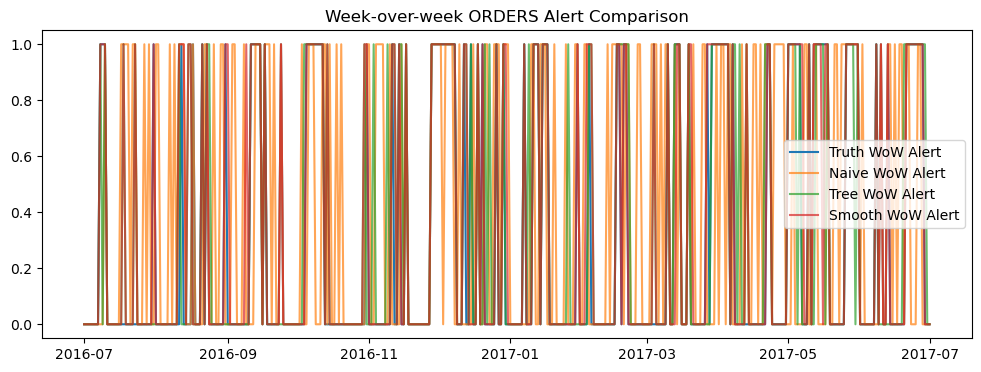

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(orders_truth_wow.index, orders_truth_wow, label="Truth WoW Alert")
plt.plot(orders_naive_wow.index, orders_naive_wow, label="Naive WoW Alert", alpha=0.7)
plt.plot(orders_tree_wow.index, orders_tree_wow, label="Tree WoW Alert", alpha=0.7)
plt.plot(orders_smooth_wow.index, orders_smooth_wow, label="Smooth WoW Alert", alpha=0.7)
plt.legend()
plt.title("Week-over-week ORDERS Alert Comparison")
plt.show()

In [7]:
# Example threshold
rev_threshold = revenue_truth.quantile(0.75)

rev_truth_thresh  = threshold_alert(revenue_truth, rev_threshold)
rev_naive_thresh  = threshold_alert(revenue_naive, rev_threshold)
rev_tree_thresh   = threshold_alert(revenue_tree, rev_threshold)
rev_smooth_thresh = threshold_alert(revenue_smooth, rev_threshold)

print("REVENUE threshold alert flip stats")
print(decision_flip_stats(rev_truth_thresh, rev_naive_thresh))
print(decision_flip_stats(rev_truth_thresh, rev_tree_thresh))
print(decision_flip_stats(rev_truth_thresh, rev_smooth_thresh))

REVENUE threshold alert flip stats
{'flip_rate': np.float64(0.46994535519125685), 'false_positive_rate': np.float64(0.35792349726775957), 'false_negative_rate': np.float64(0.11202185792349727), 'TP': np.int64(51), 'FP': np.int64(131), 'TN': np.int64(143), 'FN': np.int64(41)}
{'flip_rate': np.float64(0.2103825136612022), 'false_positive_rate': np.float64(0.1448087431693989), 'false_negative_rate': np.float64(0.06557377049180328), 'TP': np.int64(68), 'FP': np.int64(53), 'TN': np.int64(221), 'FN': np.int64(24)}
{'flip_rate': np.float64(0.30327868852459017), 'false_positive_rate': np.float64(0.2103825136612022), 'false_negative_rate': np.float64(0.09289617486338798), 'TP': np.int64(58), 'FP': np.int64(77), 'TN': np.int64(197), 'FN': np.int64(34)}


In [8]:
orders_truth_anom  = zscore_anomaly(orders_truth, window=14, z_thresh=2.5)
orders_naive_anom  = zscore_anomaly(orders_naive, window=14, z_thresh=2.5)
orders_tree_anom   = zscore_anomaly(orders_tree, window=14, z_thresh=2.5)
orders_smooth_anom = zscore_anomaly(orders_smooth, window=14, z_thresh=2.5)

In [9]:
revenue_truth_anom  = zscore_anomaly(revenue_truth, window=14, z_thresh=2.5)
revenue_naive_anom  = zscore_anomaly(revenue_naive, window=14, z_thresh=2.5)
revenue_tree_anom   = zscore_anomaly(revenue_tree, window=14, z_thresh=2.5)
revenue_smooth_anom = zscore_anomaly(revenue_smooth, window=14, z_thresh=2.5)

In [10]:
dau_truth_anom  = zscore_anomaly(dau_truth, window=14, z_thresh=2.5)
dau_naive_anom  = zscore_anomaly(dau_naive, window=14, z_thresh=2.5)
dau_tree_anom   = zscore_anomaly(dau_tree, window=14, z_thresh=2.5)
dau_smooth_anom = zscore_anomaly(dau_smooth, window=14, z_thresh=2.5)

In [ ]:
print("ORDERS z-score anomaly flip stats:")
print(" Naive:", decision_flip_stats(orders_truth_anom, orders_naive_anom))
print(" Tree:",  decision_flip_stats(orders_truth_anom, orders_tree_anom))
print("Smooth:", decision_flip_stats(orders_truth_anom, orders_smooth_anom))


ORDERS z-score anomaly flip stats:
 Naive: {'flip_rate': np.float64(0.04644808743169399), 'false_positive_rate': np.float64(0.030054644808743168), 'false_negative_rate': np.float64(0.01639344262295082), 'TP': np.int64(3), 'FP': np.int64(11), 'TN': np.int64(346), 'FN': np.int64(6)}
 Tree: {'flip_rate': np.float64(0.01366120218579235), 'false_positive_rate': np.float64(0.01092896174863388), 'false_negative_rate': np.float64(0.00273224043715847), 'TP': np.int64(8), 'FP': np.int64(4), 'TN': np.int64(353), 'FN': np.int64(1)}
Smooth: {'flip_rate': np.float64(0.01092896174863388), 'false_positive_rate': np.float64(0.00819672131147541), 'false_negative_rate': np.float64(0.00273224043715847), 'TP': np.int64(8), 'FP': np.int64(3), 'TN': np.int64(354), 'FN': np.int64(1)}
